# An initial training pipeline

In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import dask.dataframe as dd
import pandas as pd
import numpy as np

from glob import glob
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(ft_dir+'/*.parquet')
df = dd.read_parquet(ft_glob).compute().reset_index().dropna()


In [4]:
df.head()

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
1,AAON,1992-12-17,0.119716,0.129692,0.099763,0.119716,0.101691,163900.0,AAON.csv,1992,0.099763
2,AAON,1992-12-18,0.119716,0.119716,0.119716,0.119716,0.101691,14100.0,AAON.csv,1992,0.119716
3,AAON,1992-12-21,0.099763,0.099763,0.089787,0.099763,0.084743,32400.0,AAON.csv,1992,0.119716
4,AAON,1992-12-22,0.099763,0.119716,0.099763,0.119716,0.101691,62100.0,AAON.csv,1992,0.099763
5,AAON,1992-12-23,0.099763,0.099763,0.099763,0.099763,0.084743,14100.0,AAON.csv,1992,0.119716


In [5]:
cat_file = os.path.join(
    os.getenv("PRICE_CSV_DATA"), 
    'symbols_valid_meta.csv'
)
cat_df = (pd.read_csv(cat_file)
          .rename(columns = {'Symbol': 'ticker'})[['ticker', 'Listing Exchange', 'Market Category']]
          )
df = df.merge(cat_df, on = 'ticker', how = 'left')

# returns = df[['returns']]
# std_scaler.fit(returns)
# OR
# std_scaler.fit(df.returns.values.reshape(-1, 1))

## Preprocessing

+ Previously, we produced a features data set.
+ Most times, one or more [preprocessing steps](https://scikit-learn.org/stable/modules/preprocessing.html#) steps will be applied to data.
+ The most practical way to apply them is by arranging them in `Pipeline` objects, wchich are sequential transformations applied to data. 
+ It is convenient for us to label these transformations and there is a standard way of doing so.


## Transformations

+ Transformations are classes that implement `fit` and `transform` methods.

### StandardScaler

+ For example, transform a numerical variable by standardizing it.
- Standardization is removing the mean value of the feature and scale it by dividing non-constant features by their standard deviation.

$$
z = \frac{x-\mu}{\sigma}
$$


+  Using [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), one can do the following:

In [6]:
df.columns

Index(['ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'source', 'Year', 'Close_lag_1', 'Listing Exchange', 'Market Category'],
      dtype='object')

In [7]:
df = (df.assign(
        returns = lambda x: x['Close']/x['Close_lag_1'] - 1, 
        positive_return = lambda x: 1.0*(x['returns'] > 0),
        hi_lo = lambda x: x['High'] - x['Low'],
        op_cl = lambda x: x['Close'] - x['Open']
    ).groupby(['ticker'], group_keys=False).apply(
        lambda x: x.assign(target = x['positive_return'].shift(-1))
    )
    .reset_index(drop=True)
    .dropna(subset = ['target'])
    )
df

C:\Users\ekadw\AppData\Local\Temp\ipykernel_21752\619560177.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).groupby(['ticker'], group_keys=False).apply(


,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1,Listing Exchange,Market Category,returns,positive_return,hi_lo,op_cl,target
0,AAON,1992-12-17,0.119716,0.129692,0.099763,0.119716,0.101691,163900.0,AAON.csv,1992,0.099763,Q,Q,0.200000,1.0,0.029929,0.000000,0.0
1,AAON,1992-12-18,0.119716,0.119716,0.119716,0.119716,0.101691,14100.0,AAON.csv,1992,0.119716,Q,Q,0.000000,0.0,0.000000,0.000000,0.0
2,AAON,1992-12-21,0.099763,0.099763,0.089787,0.099763,0.084743,32400.0,AAON.csv,1992,0.119716,Q,Q,-0.166667,0.0,0.009976,0.000000,1.0
3,AAON,1992-12-22,0.099763,0.119716,0.099763,0.119716,0.101691,62100.0,AAON.csv,1992,0.099763,Q,Q,0.200000,1.0,0.019953,0.019953,0.0
4,AAON,1992-12-23,0.099763,0.099763,0.099763,0.099763,0.084743,14100.0,AAON.csv,1992,0.119716,Q,Q,-0.166667,0.0,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362199,ZIXI,2003-06-25,4.150000,4.180000,3.990000,4.040000,4.040000,112100.0,ZIXI.csv,2003,4.250000,Q,Q,-0.049412,0.0,0.190000,-0.110000,0.0
362200,ZIXI,2003-06-26,4.040000,4.190000,3.860000,4.000000,4.000000,515300.0,ZIXI.csv,2003,4.040000,Q,Q,-0.009901,0.0,0.330000,-0.040000,0.0
362201,ZIXI,2003-06-27,4.000000,4.050000,3.790000,3.850000,3.850000,162400.0,ZIXI.csv,2003,4.000000,Q,Q,-0.037500,0.0,0.260000,-0.150000,0.0
362202,ZIXI,2003-06-30,3.840000,4.000000,3.720000,3.770000,3.770000,119900.0,ZIXI.csv,2003,3.850000,Q,Q,-0.020779,0.0,0.280000,-0.070000,1.0


In [14]:
# Create a StandardScaler object

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

returns = df['returns'].values

# Fit the StandardScaler object with the returns data
std_scaler.fit(df.returns.values.reshape(-1, 1))

,copy,True
,with_mean,True
,with_std,True


In [18]:
# Transform the returns data using the fitted scaler

# Transform the returns data using the fitted scaler
returns = df.returns.values.reshape(-1, 1)
scaled_returns_np = std_scaler.transform(df.returns.values.reshape(-1, 1))
scaled_returns = pd.DataFrame(scaled_returns_np, columns=['returns'])
scaled_returns.describe()

,returns
count,3.621150e+05
mean,-3.139523e-19
std,1.000001e+00
min,-8.619079e-01
25%,-1.591192e-02
50%,-7.221412e-03
75%,1.473438e-03
max,4.938424e+02


###  OneHotEncoder

+ Categorical features can be encoded as numerical values using `OneHotEncoder`.

<Axes: xlabel='Listing Exchange'>

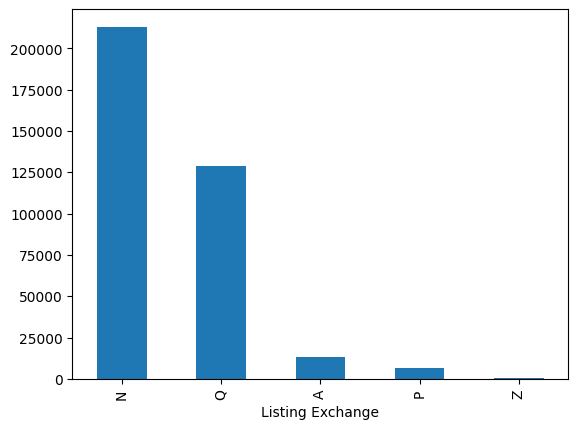

In [19]:
df['Listing Exchange'].value_counts().plot(kind = 'bar')

+ Use [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) to encode a categorical variable as numerical.
+ Important parameters:

    - `categories` allows you to specify the categories to work with.
    - `drop`: we can drop the `'first'` value (dummy encoding) or `'if_binary'`, a convenience setting for binary values.
    - `handle_unknown` allows three options, `'error'`, `'ignore'`, and `'infrequent_if_exist'`, depending on what we want to do with new values.

In [20]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder()
onehot.fit(df[['Listing Exchange']])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [21]:
listing_enc = onehot.transform(df[['Listing Exchange']])
listing_enc.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]], shape=(362115, 5))

# Pipelines

+ It is impractical and costly to manipulate data "by hand". 
+ To manage data preprocessing steps within the cross-validation process use `Pipeline` objects.
+ A [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object allows us to sequentially apply transformation steps and, if required, a predictor.
+ `Pipeline` objects compose transforms, i.e., classes that implement `transform` and `fit` methods.
+ The purpose of `Pipeline` objects is to ensemble transforms and predictors to be used in cross-validation.
+ A `Pipeline` is defined by a list of tuples.
+ Each tuple is composed of `("name", <ColumnTransformer>)`, the name of the step and the `<ColumnTransformer>` function of our chosing.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, cohen_kappa_score, f1_score


In [23]:
pipe1 = Pipeline(
    [
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ('knn', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))

    ]
)
pipe1

,steps,"[('onehot', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [24]:
X0 = df[['Listing Exchange', 'Market Category']]
Y0 = df['target']
X0_train, X0_test, Y0_train, Y0_test = train_test_split(X0, Y0, test_size=0.2, random_state=42)

pipe1.fit(X0_train, Y0_train)

,steps,"[('onehot', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [25]:
Y_pred_train = pipe1.predict(X0_train)
Y_pred_test = pipe1.predict(X0_test)

In [26]:
Y_poba_train = pipe1.predict_proba(X0_train)
Y_proba_test = pipe1.predict_proba(X0_test)

In [27]:
res = {
    'accuracy_score_train': accuracy_score(Y0_train, Y_pred_train),
    'accuracy_score_test': accuracy_score(Y0_test, Y_pred_test),
    'cohen_kappa_train': cohen_kappa_score(Y0_train, Y_pred_train),
    'cohen_kappa_test': cohen_kappa_score(Y0_test, Y_pred_test),
    'log_loss_train': log_loss(Y0_train, Y_poba_train),
    'log_loss_test': log_loss(Y0_test, Y_proba_test),
    'f1_score_train': f1_score(Y0_train, Y_pred_train),
    'f1_score_test': f1_score(Y0_test, Y_pred_test)
}
res

{'accuracy_score_train': 0.5549549176366624,
 'accuracy_score_test': 0.5553622468000498,
 'cohen_kappa_train': 0.0,
 'cohen_kappa_test': 0.0,
 'log_loss_train': 0.6868475460343753,
 'log_loss_test': 0.6867389118558428,
 'f1_score_train': 0.0,
 'f1_score_test': 0.0}

+ The model does not show great performance, but the pipeline shows results. 
+ Below, we expand the pipeline to include more variables, and further we will work with more robust model selection pipelines.

## ColumnTransformer

+ Use [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to apply transformers to specific columns of a DataFrame.
+ In this case, we will scale numeric variables and apply one-hot encoding to categorical columns.

In [28]:
from sklearn.compose import ColumnTransformer

In [29]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric_transfomer', StandardScaler(), ['returns', 'Volume', 'op_cl', 'hi_lo'] ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['Listing Exchange', 'Market Category']), 
    ], remainder='drop'
)

pipe = Pipeline(
    [
        ('preproc', transformer), 
        ('decisiontree', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))
    ]
)

# Model Selection

The model selection process is an iterative process in which :

+ Select schema and load data.
+ Define a pipeline and its (hyper) parameters.

    - Use ColumnTransformers to transform numeric and cateogrical variables.
    - Hyperparameters can be defined independently of code. 

+ Implement a splitting strategy. 

    - Use [cross_validate]() to select several metrics and operational details.

+ Measure performance.

    - [Select metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

+ Repeat

## Training, Validation, Testing Split

+ The first spliting strategy is to use a training, validation, and test set.
+ Training set will be used to fit the model.
+ Validation set is used to evaluate hyperparameter choice.
+ Testing set is used to evaluate performance on data the model has not yet seen.
+ In this case we want to compare two models: 

    - Decision Tree with 3 minumum samples per leaf.
    - Decision Tree with 10 minimum samples per leaf.

![](./images/03b_train_validate_test.png)

## Setting parameters in pipeline steps

+ One can obtain the parameters of a pipeline with `pipe.get_params()`.
+ We can set any parameter of a pipeline with `pipe.set_parames(**kwargs)`. 
+ The input `**kwargs` is a dictionary of the params to be modified. Params of the steps are labeled with the name of the step followed by `__` and the name of the parameter.

+ There are a few steps that we will repeat: 

    - Fit the candidate model on training data.
    - Predict on training and test data.
    - Compute training and test performance metrics.
    - Return.

+ We encapsulate this procedure in a function. 

In [30]:
def evaluate_model(clf, X_train, Y_train, X_test, Y_test):
    clf.fit(X_train, Y_train)
    Y_pred_train = clf.predict(X_train)
    Y_pred_test = clf.predict(X_test)
    Y_proba_train = clf.predict_proba(X_train)
    Y_proba_test = clf.predict_proba(X_test)
    performance_metrics = {
        'log_loss_train': log_loss(Y_train, Y_proba_train),
        'log_loss_test': log_loss(Y_test, Y_proba_test),
        'cohen_kappa_train': cohen_kappa_score(Y_train, Y_pred_train),
        'cohen_kappa_test': cohen_kappa_score(Y_test, Y_pred_test),
        'f1_score_train': f1_score(Y_train, Y_pred_train),
        'f1_score_test': f1_score(Y_test, Y_pred_test),
        'accuracy_score_train': accuracy_score(Y_train, Y_pred_train),
        'accuracy_score_test': accuracy_score(Y_test, Y_pred_test),
    }
    return performance_metrics

In [31]:
# Schema
X = df[['returns', 'op_cl', 'hi_lo', 'Volume', 'Listing Exchange', 'Market Category']]
Y = df['target']

# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)


In [32]:
# Evaluate hyperparameter configuration 2
pipe_d3 = pipe.set_params(**{'decisiontree__max_depth': 3})
res_d3 = evaluate_model(pipe_d3, X_train, Y_train, X_validate, Y_validate)
res_d3

{'log_loss_train': 0.6741126650323994,
 'log_loss_test': 0.6739668830207028,
 'cohen_kappa_train': 0.0002844083019379884,
 'cohen_kappa_test': 0.00028999188420686384,
 'f1_score_train': 0.0006207505261830633,
 'f1_score_test': 0.0007728572532653219,
 'accuracy_score_train': 0.555401656073492,
 'accuracy_score_test': 0.553703032499698}

In [33]:
# Evaluate hyperparameter configuration 2
pipe_d15 = pipe.set_params(**{'decisiontree__max_depth':15})
res_d15 = evaluate_model(pipe_d15, X_train, Y_train, X_validate, Y_validate)
res_d15

{'log_loss_train': 0.6298985835836078,
 'log_loss_test': 1.397877639080555,
 'cohen_kappa_train': 0.15711140556536063,
 'cohen_kappa_test': 0.07321074766120728,
 'f1_score_train': 0.49319086977003124,
 'f1_score_test': 0.44615286597149956,
 'accuracy_score_train': 0.5914788589575971,
 'accuracy_score_test': 0.5498886760213327}

## Cross-Validation

+ Cross-validation is a resampling method.
+ It is an iterative method applied to training data.
+ Training data is divided into folds.
+ Each fold is used once as a validation set and the rest of the folds are used for training.
+ Test data is used for final evaluation.

From [Scikit's Documentation ](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance), the diagram below shows the data divisions and folds during the cross-validation process.

![](./images/03b_grid_search_cross_validation.png)

There are two functions that can be used for [calculating cross-validation performance scores](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance): `cross_val_score()` and `cross_validate()`. The first function, [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score), is a convenience function to get quick perfromance calculations. We will discuss `cross_validate()` as it offers advantages over `cross_val_score()`.

## Obtaining metrics

+ Use [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) to measure one or more performance metrics and operational details.
+ There are two advantages of using this function. From [Scikit's documentation](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation):

>- It allows specifying multiple metrics for evaluation.
>- It returns a dict containing fit-times, score-times (and optionally training scores, fitted estimators, train-test split indices) in addition to the test score.


In [34]:
from sklearn.model_selection import cross_validate
scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'neg_log_loss', 'neg_brier_score']
d3_dict = cross_validate(pipe_d3, X, Y, cv=5, scoring = scoring, return_train_score = True)

In DataFrame form:

In [35]:
pd.DataFrame(d3_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,4.669256,0.251005,0.546608,0.588311,0.392286,0.446753,0.485991,0.555616,0.328875,0.373560,0.542150,0.637614,-2.843994,-0.631600,-0.275774,-0.225151
1,4.581621,0.314003,0.520208,0.586937,0.408021,0.487470,0.452348,0.544191,0.371606,0.441456,0.514819,0.633667,-3.300418,-0.637787,-0.292694,-0.227000
2,4.584460,0.242023,0.530343,0.589523,0.393863,0.437981,0.462578,0.560415,0.342922,0.359451,0.521553,0.641153,-1.646563,-0.630419,-0.266005,-0.224367
3,4.679020,0.265000,0.538392,0.589319,0.358687,0.405320,0.469728,0.569782,0.290107,0.314534,0.548944,0.637641,-2.032690,-0.633527,-0.266206,-0.225651
4,4.575903,0.291735,0.540657,0.590848,0.385185,0.481877,0.476214,0.551942,0.323372,0.427596,0.543420,0.641302,-2.030886,-0.629841,-0.265940,-0.224327


In [36]:
d15_dict = cross_validate(pipe_d15, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(d15_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,4.705157,0.289967,0.547823,0.588314,0.393039,0.447093,0.487965,0.555538,0.329030,0.374072,0.544703,0.637673,-2.779313,-0.631435,-0.274321,-0.225096
1,4.650395,0.254559,0.519683,0.586934,0.407131,0.487472,0.451586,0.544185,0.370644,0.441464,0.514056,0.633687,-3.317546,-0.637769,-0.293077,-0.226992
2,4.685194,0.265128,0.530522,0.589533,0.394429,0.437945,0.462899,0.560447,0.343605,0.359389,0.521942,0.641167,-1.633385,-0.630426,-0.265796,-0.224367
3,4.653490,0.244009,0.538986,0.589385,0.358515,0.405668,0.470689,0.569832,0.289518,0.314937,0.549944,0.637746,-2.012247,-0.633476,-0.265618,-0.225633
4,4.822735,0.281000,0.541002,0.590879,0.385341,0.482086,0.476757,0.551948,0.323341,0.427922,0.543726,0.641274,-2.060828,-0.629862,-0.266136,-0.224333


# About Performance

+ Notice that in order to acquire information about our model and continue development, we are spending resources: time, electricity, equipment use, etc. As well, we are generating data and binary objects that implement our models (fitted `Pipeline` objects, for example).
+ For certain applications, operating performance (latency or `'score_time'`) may be as important or more important than predictive performance metrics. 
+ Every experiment throws important information and we can log them, as well as run them systematically.

In [37]:
pd.DataFrame(d15_dict).mean()

fit_time                 4.703394
score_time               0.266933
test_accuracy            0.535603
train_accuracy           0.589009
test_f1                  0.387691
train_f1                 0.452053
test_precision           0.469979
train_precision          0.556390
test_recall              0.331228
train_recall             0.383557
test_roc_auc             0.534874
train_roc_auc            0.638309
test_neg_log_loss       -2.360664
train_neg_log_loss      -0.632594
test_neg_brier_score    -0.272990
train_neg_brier_score   -0.225284
dtype: float64